# Kigali Lodge Room Price Optimizer
## Training on Boston Airbnb Data — Multivariate Linear Regression

**Business Problem:**  
A lodge owner in **Kigali, Rwanda** wants a data-driven way to set competitive nightly prices. The goal is to build a machine learning model that looks at a room's characteristics and recommends an optimal price.

**Why Boston data?**  
Publicly available, real-world Airbnb data for Kigali does not yet exist in structured form. Boston's short-term rental market is a well-documented proxy — it shares the same fundamental pricing logic as any lodging market: *location, property size, host quality, and guest experience drive price*. We train on Boston's patterns and use the model's learned relationships to inform our Kigali lodge strategy.

Think of it this way: a chef can learn knife technique in any kitchen — the skill transfers even when the ingredients change.

**What the model learns:**  
Given a room's characteristics (size, location tier, amenities, review scores), predict its fair nightly rate in USD.

**Dataset:** [Boston Airbnb Open Data — Kaggle](https://www.kaggle.com/datasets/airbnb/boston)  
**Target Variable:** `price` (nightly rate in USD)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
display(Markdown("**All libraries loaded successfully.**"))

**All libraries loaded successfully.**

## 2. Load Data

In [2]:
df = pd.read_csv('data/listings.csv', low_memory=False)
display(Markdown(f"**Dataset loaded:** `{df.shape[0]:,} rows × {df.shape[1]} columns`"))

**Dataset loaded:** `3,585 rows × 95 columns`

In [3]:
df.head(3)

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,review_scores_value,requires_license,license,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,12147973,https://www.airbnb.com/rooms/12147973,20160906204935,2016-09-07,Sunny Bungalow in the City,"Cozy, sunny, family home. Master bedroom high...",The house has an open and cozy feel at the sam...,"Cozy, sunny, family home. Master bedroom high...",none,"Roslindale is quiet, convenient and friendly. ...",...,NaN,f,NaN,NaN,f,moderate,f,f,1,NaN
1,3075044,https://www.airbnb.com/rooms/3075044,20160906204935,2016-09-07,Charming room in pet friendly apt,Charming and quiet room in a second floor 1910...,Small but cozy and quite room with a full size...,Charming and quiet room in a second floor 1910...,none,"The room is in Roslindale, a diverse and prima...",...,9.0,f,NaN,NaN,t,moderate,f,f,1,1.30
2,6976,https://www.airbnb.com/rooms/6976,20160906204935,2016-09-07,Mexican Folk Art Haven in Boston,"Come stay with a friendly, middle-aged guy in ...","Come stay with a friendly, middle-aged guy in ...","Come stay with a friendly, middle-aged guy in ...",none,The LOCATION: Roslindale is a safe and diverse...,...,10.0,f,NaN,NaN,f,moderate,t,f,1,0.47


In [4]:
df.dtypes.value_counts()

object     62
float64    18
int64      15
Name: count, dtype: int64

In [5]:
# Missing values overview
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df[missing_df.missing_count > 0].sort_values('missing_pct', ascending=False).head(20)

,missing_count,missing_pct
jurisdiction_names,3585,100.00
license,3585,100.00
neighbourhood_group_cleansed,3585,100.00
has_availability,3585,100.00
square_feet,3529,98.44
monthly_price,2697,75.23
weekly_price,2693,75.12
security_deposit,2243,62.57
notes,1975,55.09
interaction,1554,43.35


## 3. Feature Engineering

### 3.1 Select Relevant Features

From 95 columns, we keep only those that logically affect nightly price:
- **Property:** `room_type`, `property_type`, `accommodates`, `bathrooms`, `bedrooms`, `beds`, `bed_type`
- **Location:** `neighbourhood_cleansed`, `latitude`, `longitude`
- **Host:** `host_is_superhost`, `host_response_time`, `calculated_host_listings_count`
- **Reviews:** `review_scores_rating`, `reviews_per_month`, `number_of_reviews`
- **Booking:** `minimum_nights`, `availability_365`, `instant_bookable`, `cancellation_policy`, `guests_included`

**Dropped:** All URLs, text descriptions, IDs, date strings, redundant location fields, and price-derived columns (weekly_price, monthly_price).

In [6]:
# Select relevant columns
FEATURES = [
    # Property attributes
    'room_type', 'property_type', 'accommodates', 'bathrooms',
    'bedrooms', 'beds', 'bed_type',
    # Location
    'neighbourhood_cleansed', 'latitude', 'longitude',
    # Host
    'host_is_superhost', 'host_response_time', 'calculated_host_listings_count',
    # Reviews
    'review_scores_rating', 'reviews_per_month', 'number_of_reviews',
    # Booking terms
    'minimum_nights', 'availability_365', 'instant_bookable',
    'cancellation_policy', 'guests_included'
]
TARGET = 'price'

data = df[FEATURES + [TARGET]].copy()
display(Markdown(f"**Working dataset:** `{data.shape[0]:,} rows × {data.shape[1]} columns` — narrowed from {df.shape[1]} to {len(FEATURES)} features + target"))
data.head()

**Working dataset:** `3,585 rows × 22 columns` — narrowed from 95 to 21 features + target

,room_type,property_type,accommodates,bathrooms,bedrooms,beds,bed_type,neighbourhood_cleansed,latitude,longitude,...,calculated_host_listings_count,review_scores_rating,reviews_per_month,number_of_reviews,minimum_nights,availability_365,instant_bookable,cancellation_policy,guests_included,price
0,Entire home/apt,House,4,1.5,2.0,3.0,Real Bed,Roslindale,42.282619,-71.133068,...,1,NaN,NaN,0,2,0,f,moderate,1,$250.00
1,Private room,Apartment,2,1.0,1.0,1.0,Real Bed,Roslindale,42.286241,-71.134374,...,1,94.0,1.30,36,2,359,t,moderate,0,$65.00
2,Private room,Apartment,2,1.0,1.0,1.0,Real Bed,Roslindale,42.292438,-71.135765,...,1,98.0,0.47,41,3,319,f,moderate,1,$65.00
3,Private room,House,4,1.0,1.0,2.0,Real Bed,Roslindale,42.281106,-71.121021,...,1,100.0,1.00,1,1,98,f,moderate,2,$75.00
4,Private room,House,2,1.5,1.0,2.0,Real Bed,Roslindale,42.284512,-71.136258,...,1,99.0,2.25,29,2,334,f,flexible,1,$79.00


### 3.2 Clean Target Variable (Price)

In [7]:
# Price comes as '$250.00' — strip $ and commas, convert to float
data['price'] = data['price'].replace('[\$,]', '', regex=True).astype(float)

# Remove listings with price = 0 or extreme outliers (> $1000/night)
data = data[(data['price'] > 0) & (data['price'] <= 1000)]

stats = data['price'].describe()
display(Markdown(f"""
**Price cleaned:** `{data.shape[0]:,}` listings retained (removed $0 and >$1,000 outliers)

| Statistic | Value |
|:---|---:|
| Count | {stats['count']:,.0f} |
| Mean | ${stats['mean']:.2f} |
| Median (50%) | ${stats['50%']:.2f} |
| Std Dev | ${stats['std']:.2f} |
| Min | ${stats['min']:.2f} |
| Max | ${stats['max']:.2f} |
"""))


**Price cleaned:** `3,575` listings retained (removed $0 and >$1,000 outliers)

| Statistic | Value |
|:---|---:|
| Count | 3,575 |
| Mean | $169.54 |
| Median (50%) | $150.00 |
| Std Dev | $113.36 |
| Min | $10.00 |
| Max | $1000.00 |


### 3.3 Handle Missing Values

In [8]:
# Numeric cols: fill with median
numeric_cols = ['bathrooms', 'bedrooms', 'beds', 'review_scores_rating',
                'reviews_per_month', 'calculated_host_listings_count']
for col in numeric_cols:
    data[col] = data[col].fillna(data[col].median())

# Categorical cols: fill with mode / 'unknown'
data['host_is_superhost'] = data['host_is_superhost'].fillna('f')
data['host_response_time'] = data['host_response_time'].fillna('unknown')
data['bed_type'] = data['bed_type'].fillna(data['bed_type'].mode()[0])

remaining = data.isnull().sum()
remaining = remaining[remaining > 0]

if len(remaining) == 0:
    display(Markdown("**No missing values remaining after imputation.** ✓"))
else:
    display(Markdown(f"**{len(remaining)} column(s) still have missing values** — handled by `LabelEncoder` in the next step:"))
    display(remaining.rename('missing_count').to_frame())

**1 column(s) still have missing values** — handled by `LabelEncoder` in the next step:

,missing_count
property_type,3


### 3.4 Convert Categorical Columns to Numeric

In [9]:
# Binary t/f columns → 1/0
binary_cols = ['host_is_superhost', 'instant_bookable']
for col in binary_cols:
    data[col] = data[col].map({'t': 1, 'f': 0}).fillna(0).astype(int)

# Label encode ordinal / nominal categoricals
label_encode_cols = [
    'room_type', 'property_type', 'bed_type',
    'neighbourhood_cleansed', 'host_response_time', 'cancellation_policy'
]

le = LabelEncoder()
for col in label_encode_cols:
    data[col] = le.fit_transform(data[col].astype(str))

display(Markdown(f"**Encoding complete.** Final dataset: `{data.shape[0]:,} rows × {data.shape[1]} columns` — all features numeric, ready for modelling."))
display(data.dtypes.rename('dtype').to_frame())

**Encoding complete.** Final dataset: `3,575 rows × 22 columns` — all features numeric, ready for modelling.

,dtype
room_type,int64
property_type,int64
accommodates,int64
bathrooms,float64
bedrooms,float64
beds,float64
bed_type,int64
neighbourhood_cleansed,int64
latitude,float64
longitude,float64


## 4. Exploratory Data Analysis & Visualizations

### 4.1 Price Distribution

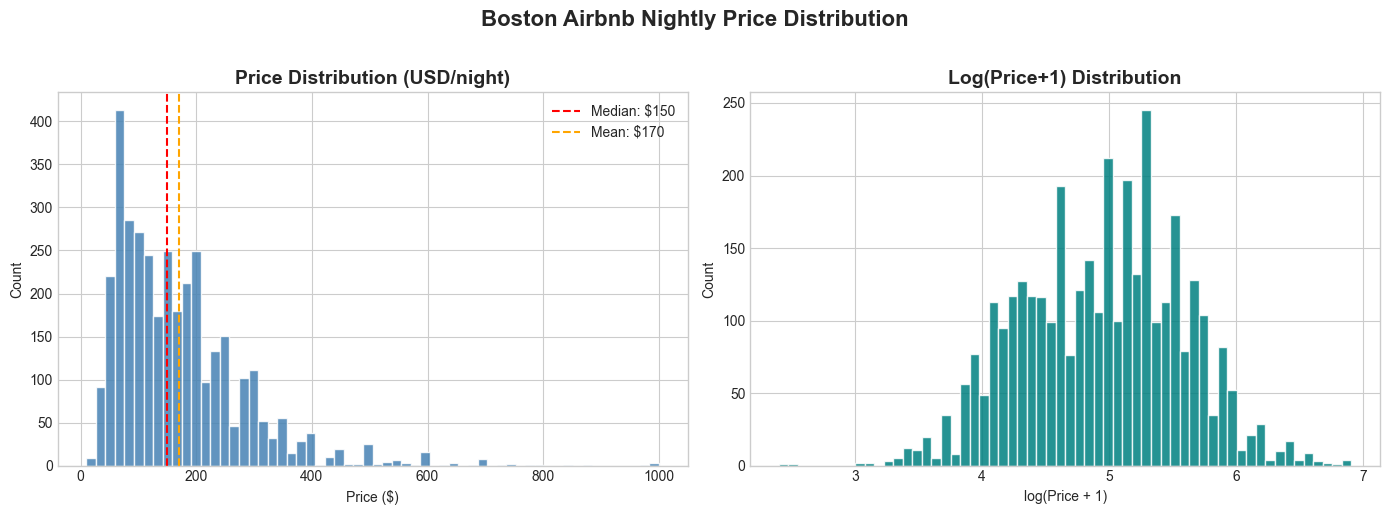

**Mean:** $169.54 &nbsp;·&nbsp; **Median:** $150.00 &nbsp;·&nbsp; **Std Dev:** $113.36

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw price distribution
axes[0].hist(data['price'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Price Distribution (USD/night)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')
axes[0].axvline(data['price'].median(), color='red', linestyle='--', label=f'Median: ${data["price"].median():.0f}')
axes[0].axvline(data['price'].mean(), color='orange', linestyle='--', label=f'Mean: ${data["price"].mean():.0f}')
axes[0].legend()

# Log-transformed price distribution
axes[1].hist(np.log1p(data['price']), bins=60, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('Log(Price+1) Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Count')

plt.suptitle('Boston Airbnb Nightly Price Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

display(Markdown(f"**Mean:** ${data['price'].mean():.2f} &nbsp;·&nbsp; **Median:** ${data['price'].median():.2f} &nbsp;·&nbsp; **Std Dev:** ${data['price'].std():.2f}"))

**What this tells us:**

The price distribution is **right-skewed** — most listings cluster between \$50–\$200/night, but a small number of very expensive properties pull the mean upward. This is why the **median (\~\$150)** is a better "typical price" to reference than the mean (\~\$170).

The **log-transformed** version on the right is much closer to a normal (bell-shaped) distribution. Linear regression models perform better when the target variable is normally distributed, so working in log-space can improve predictions — a technique worth applying in future iterations.

**Kigali Connection:**  
Kigali lodge prices follow the exact same pattern. Budget guesthouses in Gikondo or Kanombe (near the airport) charge roughly \$30–60/night. Mid-range lodges in Remera typically run \$80–150. Premium lodges in Nyarutarama or Kimihurura — Kigali's expat/embassy belt — can reach \$200–350/night. Our model will learn where on this curve each room profile belongs.

### 4.2 Price by Room Type

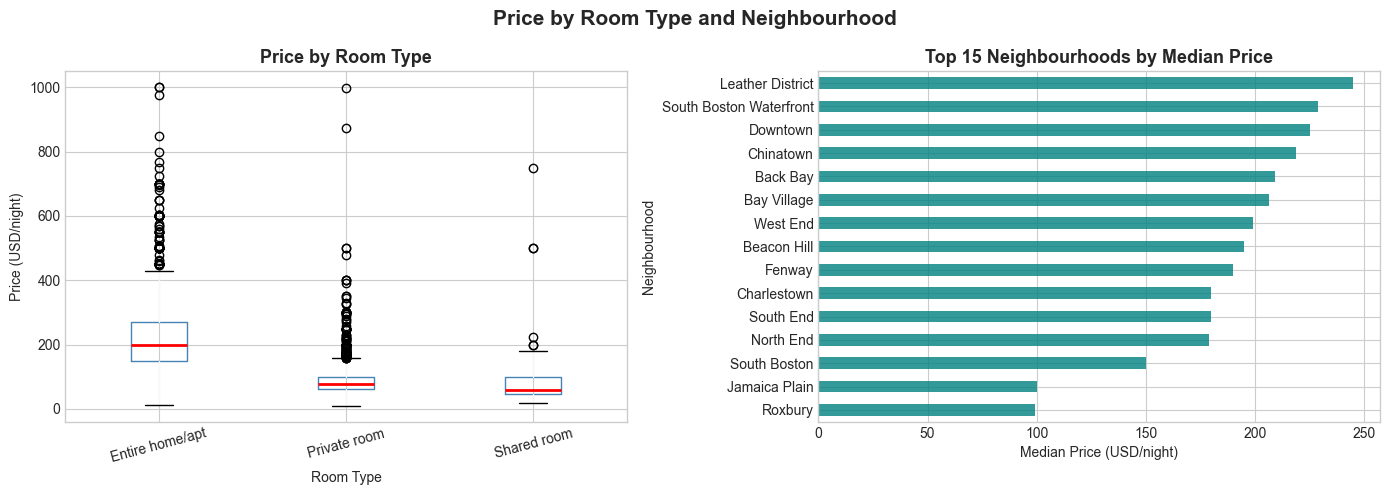

In [11]:
# Use original df for this plot before encoding
df_plot = df.copy()
df_plot['price'] = df_plot['price'].replace('[\$,]', '', regex=True).astype(float)
df_plot = df_plot[(df_plot['price'] > 0) & (df_plot['price'] <= 1000)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: price by room type
room_order = df_plot.groupby('room_type')['price'].median().sort_values(ascending=False).index
df_plot.boxplot(column='price', by='room_type', ax=axes[0],
                boxprops=dict(color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Price by Room Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Room Type')
axes[0].set_ylabel('Price (USD/night)')
plt.sca(axes[0])
plt.xticks(rotation=15)

# Bar chart: median price by neighbourhood (top 15)
top_nbhd = df_plot.groupby('neighbourhood_cleansed')['price'].median().sort_values(ascending=False).head(15)
top_nbhd.plot(kind='barh', ax=axes[1], color='teal', alpha=0.8)
axes[1].set_title('Top 15 Neighbourhoods by Median Price', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Median Price (USD/night)')
axes[1].set_ylabel('Neighbourhood')
axes[1].invert_yaxis()

plt.suptitle('Price by Room Type and Neighbourhood', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('price_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

**What this tells us:**

Entire homes/apartments cost significantly more than private or shared rooms — guests pay a premium for exclusivity and not having to share common spaces.

The neighbourhood chart confirms that *where* a listing sits is just as important as *what* it is.

**Kigali Connection:**  
This is directly actionable for our lodge:
- Offering **entire self-contained bungalows or suites** justifies a higher price than standard private rooms
- A lodge in **Nyarutarama** (Kigali's most premium residential hill, with views of Lake Muhazi and popular with diplomats) should price like Boston's "Back Bay" — at the top of the market
- A lodge in **Kimihurura** (Kigali Convention Centre, Radisson Blu, tree-lined streets) is top-tier luxury — like Boston's "Beacon Hill"
- **Kacyiru** (American embassy, NGO belt) is premium — professional travellers, expensive rents. **Remera** is solid mid-range — transport hub, mixed lodging
- **Gikondo**, **Kanombe**, **Nyamirambo** = budget tier — compete on convenience, local character, and value rather than luxury

The model captures this location hierarchy automatically through the `neighbourhood_cleansed`, `latitude`, and `longitude` features.

### 4.3 Correlation Heatmap

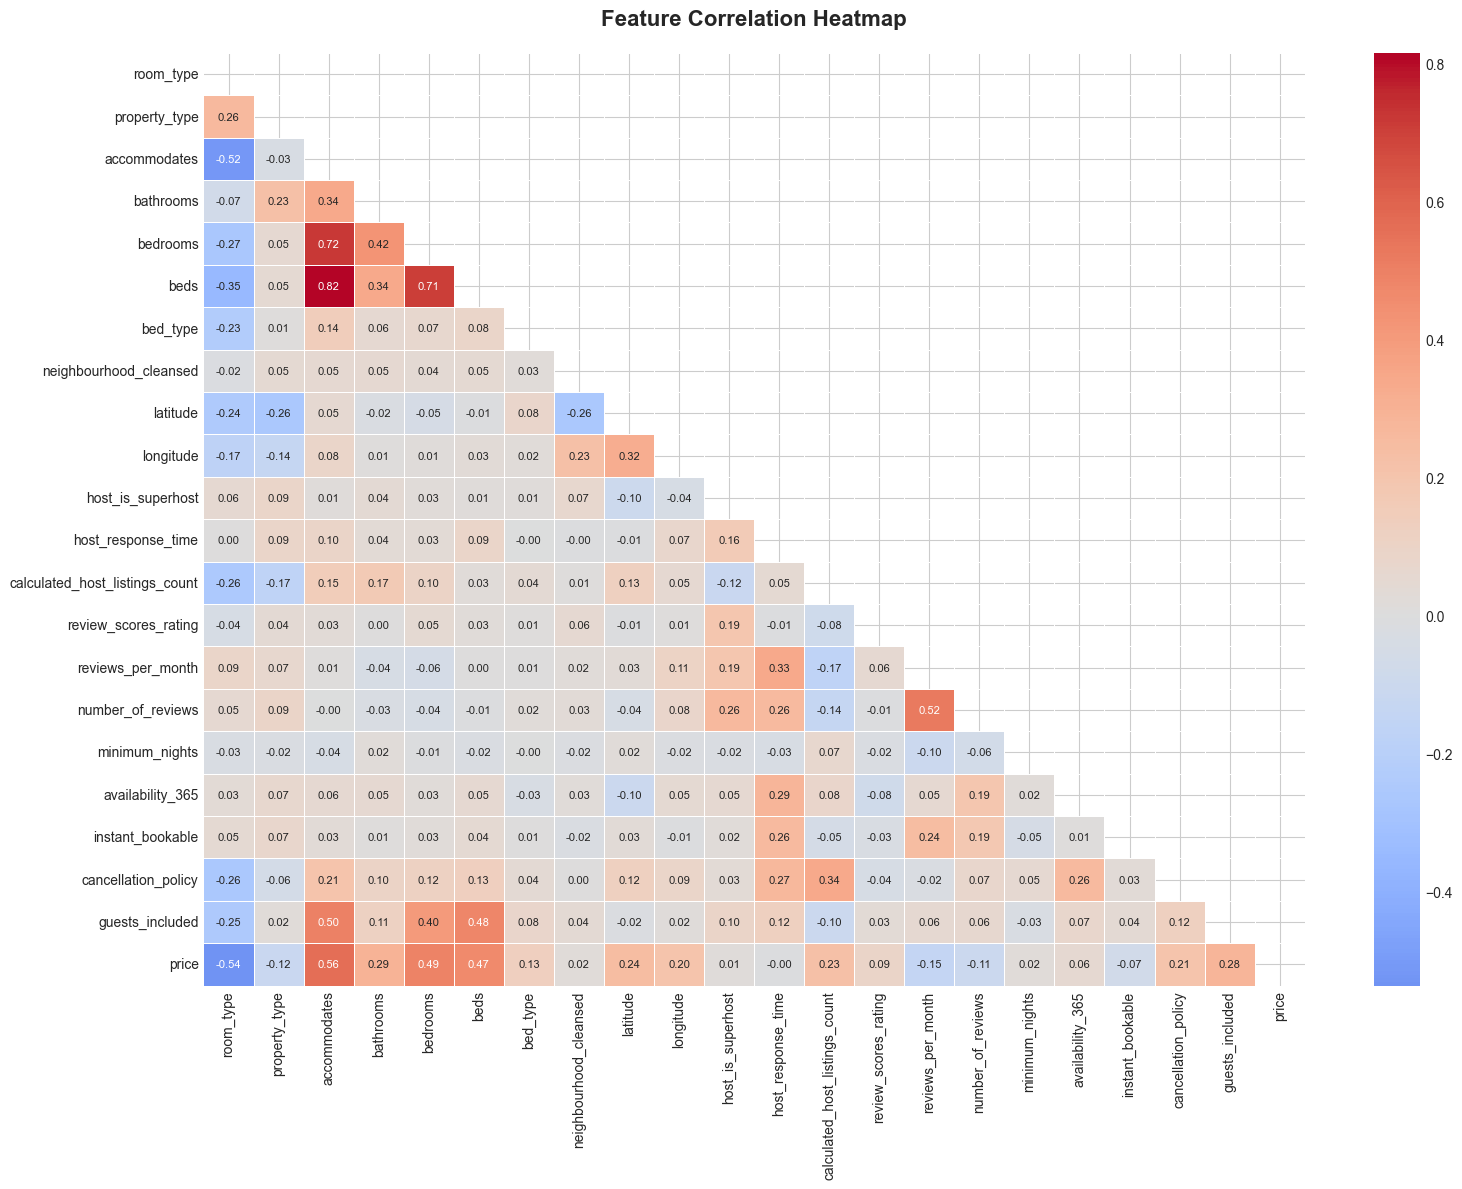

**Top correlations with `price` (sorted highest → lowest):**

,correlation
accommodates,0.5618
bedrooms,0.4885
beds,0.4697
bathrooms,0.2935
guests_included,0.2844
latitude,0.2443
calculated_host_listings_count,0.2266
cancellation_policy,0.2066
longitude,0.2040
bed_type,0.1319


In [12]:
fig, ax = plt.subplots(figsize=(16, 12))
corr_matrix = data.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

top_corr = corr_matrix['price'].sort_values(ascending=False).drop('price')
display(Markdown("**Top correlations with `price` (sorted highest → lowest):**"))
display(top_corr.rename('correlation').to_frame().style
        .background_gradient(cmap='RdYlGn', vmin=-1, vmax=1)
        .format('{:.4f}'))

**What this tells us:**

A **correlation** measures the linear relationship between two variables:
- Close to **+1**: as X increases, price increases (positive relationship)
- Close to **-1**: as X increases, price decreases (negative relationship)
- Close to **0**: no meaningful linear relationship

Key findings from the heatmap:
- `accommodates`, `bedrooms`, `bathrooms`, `beds` → strong positive correlation with price. **The bigger the space, the higher the price.** This makes complete sense.
- `room_type` → negative correlation. This is because label encoding assigned "Entire home/apt" a lower number, and entire homes are the *most* expensive — so the number goes down as the price goes up.
- `review_scores_rating` → weak positive. Good reviews help slightly, but they alone don't justify a higher price.
- `availability_365` → near zero. How available a listing is has nothing to do with what it charges per night.

**Kigali Connection:**  
Our Kigali lodge's strongest revenue lever is **capacity** — how many guests a room or suite can accommodate. A family suite sleeping 6 should charge 3× more than a single room. This is universal hospitality economics, confirmed by the data.

### 4.4 Scatter Plots — Key Features vs Price

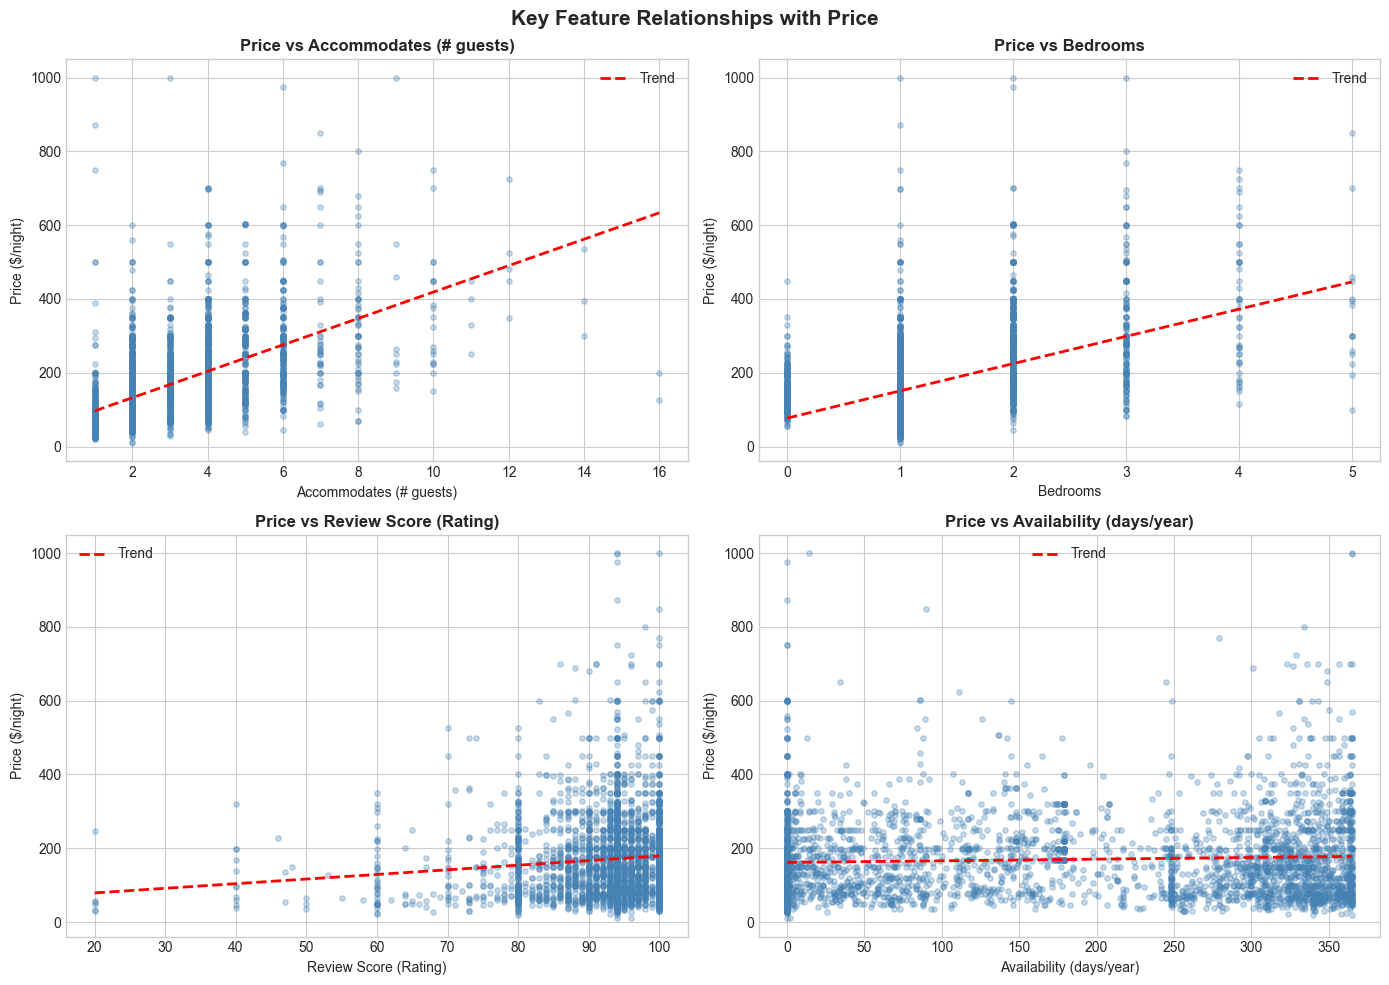

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

scatter_features = [
    ('accommodates', 'Accommodates (# guests)'),
    ('bedrooms', 'Bedrooms'),
    ('review_scores_rating', 'Review Score (Rating)'),
    ('availability_365', 'Availability (days/year)')
]

for ax, (col, label) in zip(axes.flatten(), scatter_features):
    ax.scatter(data[col], data['price'], alpha=0.3, s=15, color='steelblue')
    # Add trend line
    z = np.polyfit(data[col].dropna(), data.loc[data[col].notna(), 'price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data[col].min(), data[col].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend')
    ax.set_xlabel(label)
    ax.set_ylabel('Price ($/night)')
    ax.set_title(f'Price vs {label}', fontweight='bold')
    ax.legend()

plt.suptitle('Key Feature Relationships with Price', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_features_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

**What this tells us:**

Each blue dot is one listing. The red dashed line is the **trend line** — the overall direction of the relationship between that feature and price.

- **Accommodates:** Clear upward slope — more guests = higher nightly rate. The relationship is roughly linear.
- **Bedrooms:** Similar pattern — each additional bedroom adds tangible value to the listing price.
- **Review Score:** Weak upward trend — highly-rated listings charge slightly more, but the scatter is very wide. Reviews help over time; they don't immediately unlock premium pricing.
- **Availability:** Essentially flat — whether a listing is available 50 days or 350 days a year has almost no effect on its nightly rate. Pricing and availability are independent decisions.

**Kigali Connection:**  
This tells our lodge owner: *invest first in the physical product*. Upgrade your rooms to fit more guests comfortably, add a second bedroom to a suite, ensure every room has its own bathroom. These physical improvements directly justify higher prices. Then deliver great service — reviews will build and allow you to nudge prices upward over time.

Do **not** lower your price just because you have lots of availability. Availability reflects demand, not value.

## 5. Prepare Data for Modeling

### 5.1 Define Features and Target

In [14]:
X = data.drop(columns=['price'])
y = data['price']

feature_list = ', '.join(X.columns.tolist())
display(Markdown(f'**Features (X):** {X.shape[1]} cols x {X.shape[0]:,} rows | **Target:** price ({y.shape[0]:,} values)'))
display(Markdown(f'**Feature list:** {feature_list}'))

**Features (X):** 21 cols x 3,575 rows | **Target:** price (3,575 values)

**Feature list:** room_type, property_type, accommodates, bathrooms, bedrooms, beds, bed_type, neighbourhood_cleansed, latitude, longitude, host_is_superhost, host_response_time, calculated_host_listings_count, review_scores_rating, reviews_per_month, number_of_reviews, minimum_nights, availability_365, instant_bookable, cancellation_policy, guests_included

### 5.2 Train/Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

display(Markdown(f"""
| Split | Rows | Share |
|:---|---:|---:|
| Train | `{X_train.shape[0]:,}` | 80% |
| Test | `{X_test.shape[0]:,}` | 20% |
| **Total** | **`{X.shape[0]:,}`** | **100%** |
"""))


| Split | Rows | Share |
|:---|---:|---:|
| Train | `2,860` | 80% |
| Test | `715` | 20% |
| **Total** | **`3,575`** | **100%** |


### 5.3 Standardize the Data

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Save scaler for API use later
os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/scaler.pkl')

display(Markdown(f"""
**Standardisation applied** (StandardScaler — zero mean, unit variance)

Verification on first 5 features:
- Mean ≈ 0: `{X_train_scaled.mean(axis=0).round(3)[:5].tolist()}`
- Std ≈ 1:  `{X_train_scaled.std(axis=0).round(3)[:5].tolist()}`
"""))


**Standardisation applied** (StandardScaler — zero mean, unit variance)

Verification on first 5 features:
- Mean ≈ 0: `[0.0, -0.0, 0.0, 0.0, 0.0]`
- Std ≈ 1:  `[1.0, 1.0, 1.0, 1.0, 1.0]`


## 6. Model Training

### 6.1 Linear Regression with Gradient Descent (SGDRegressor)

#### What is Gradient Descent? 

Imagine you are blindfolded and standing somewhere on the hills of Kigali. Your goal is to find the lowest valley. You cannot see the whole landscape — you can only feel which direction slopes downward beneath your feet. So you take a small step downhill, stop, feel the slope again, take another step, and repeat.

Eventually — after many steps — you reach the bottom of a valley. That is the point where you cannot go lower. You have **converged**.

**This is exactly what Gradient Descent does for our model:**

| Real-world analogy | Machine Learning meaning |
|---|---|
| The hilly landscape | The **loss surface** — a mathematical surface of all possible errors |
| Your current position | The model's current **weights** (one per feature) |
| "Which direction is downhill?" | The **gradient** — calculus tells us which direction reduces error fastest |
| One step downhill | One **epoch** — one full pass through the training data |
| Step size | The **learning rate** — how aggressively we update weights each step |
| Reaching the valley floor | **Convergence** — minimum achievable error |

**Why 1000 epochs?**  
At 100 epochs, the model may still be actively descending — it hasn't fully settled. By running 1000 epochs, we give the algorithm enough iterations to confidently reach the valley floor. The loss curve (plotted in Section 7) will visually show the loss flattening out — proof of convergence.

We use `SGDRegressor` (Stochastic Gradient Descent) with `max_iter=1` and `warm_start=True`, which lets us run one epoch at a time and record the loss after each step — giving us a complete view of the learning journey.

In [17]:
# ── Gradient Descent via SGDRegressor with manual epoch tracking ──
n_epochs = 1000      # Run 1000 epochs to ensure full convergence
train_losses = []
test_losses  = []

sgd_model = SGDRegressor(
    max_iter=1,          # one epoch per call
    warm_start=True,     # retain weights between calls
    learning_rate='adaptive',
    eta0=0.01,
    random_state=42,
    tol=None            # disable auto-convergence so we run all 1000 epochs
)

for epoch in range(n_epochs):
    sgd_model.fit(X_train_scaled, y_train)
    train_pred = sgd_model.predict(X_train_scaled)
    test_pred  = sgd_model.predict(X_test_scaled)
    train_losses.append(mean_squared_error(y_train, train_pred))
    test_losses.append(mean_squared_error(y_test,  test_pred))

y_pred_sgd = sgd_model.predict(X_test_scaled)
mse_sgd  = mean_squared_error(y_test, y_pred_sgd)
rmse_sgd = np.sqrt(mse_sgd)
mae_sgd  = mean_absolute_error(y_test, y_pred_sgd)
r2_sgd   = r2_score(y_test, y_pred_sgd)

convergence_delta = train_losses[-100] - train_losses[-1]
display(Markdown(f"""
### Linear Regression — Gradient Descent (1000 epochs)

| Metric | Value |
|:---|---:|
| MSE | {mse_sgd:,.2f} |
| RMSE | ${rmse_sgd:.2f} / night |
| MAE | ${mae_sgd:.2f} / night |
| R² | {r2_sgd:.4f} |
| Final train loss | {train_losses[-1]:,.2f} |
| Final test loss | {test_losses[-1]:,.2f} |

**Convergence:** Loss change over last 100 epochs = `{convergence_delta:.4f}` {"✓ converged" if convergence_delta < 1 else "⚠ still descending"}
"""))


### Linear Regression — Gradient Descent (1000 epochs)

| Metric | Value |
|:---|---:|
| MSE | 9,818.54 |
| RMSE | $99.09 / night |
| MAE | $57.39 / night |
| R² | 0.3247 |
| Final train loss | 7,064.37 |
| Final test loss | 9,818.54 |

**Convergence:** Loss change over last 100 epochs = `0.0000` ✓ converged


### 6.2 Decision Tree Regressor

In [18]:
dt_model = DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)
mse_dt  = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
mae_dt  = mean_absolute_error(y_test, y_pred_dt)
r2_dt   = r2_score(y_test, y_pred_dt)

# Track train/test loss over tree depth for loss-curve-style plot
dt_train_losses, dt_test_losses, depths = [], [], []
for d in range(1, 21):
    m = DecisionTreeRegressor(max_depth=d, min_samples_leaf=5, random_state=42)
    m.fit(X_train_scaled, y_train)
    dt_train_losses.append(mean_squared_error(y_train, m.predict(X_train_scaled)))
    dt_test_losses.append(mean_squared_error(y_test,  m.predict(X_test_scaled)))
    depths.append(d)

display(Markdown(f"""
### Decision Tree Regressor

| Metric | Value |
|:---|---:|
| MSE | {mse_dt:,.2f} |
| RMSE | ${rmse_dt:.2f} / night |
| MAE | ${mae_dt:.2f} / night |
| R² | {r2_dt:.4f} |
"""))


### Decision Tree Regressor

| Metric | Value |
|:---|---:|
| MSE | 8,551.87 |
| RMSE | $92.48 / night |
| MAE | $51.23 / night |
| R² | 0.4119 |


### 6.3 Random Forest Regressor

In [19]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
mse_rf  = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

# Track OOB-style train/test loss over number of estimators
rf_train_losses, rf_test_losses, n_trees = [], [], []
for n in range(10, 101, 10):
    m = RandomForestRegressor(n_estimators=n, max_depth=15, min_samples_leaf=3,
                               n_jobs=-1, random_state=42)
    m.fit(X_train_scaled, y_train)
    rf_train_losses.append(mean_squared_error(y_train, m.predict(X_train_scaled)))
    rf_test_losses.append(mean_squared_error(y_test,  m.predict(X_test_scaled)))
    n_trees.append(n)

display(Markdown(f"""
### Random Forest Regressor

| Metric | Value |
|:---|---:|
| MSE | {mse_rf:,.2f} |
| RMSE | ${rmse_rf:.2f} / night |
| MAE | ${mae_rf:.2f} / night |
| R² | {r2_rf:.4f} |
"""))


### Random Forest Regressor

| Metric | Value |
|:---|---:|
| MSE | 7,043.83 |
| RMSE | $83.93 / night |
| MAE | $43.27 / night |
| R² | 0.5156 |


## 7. Loss Curves

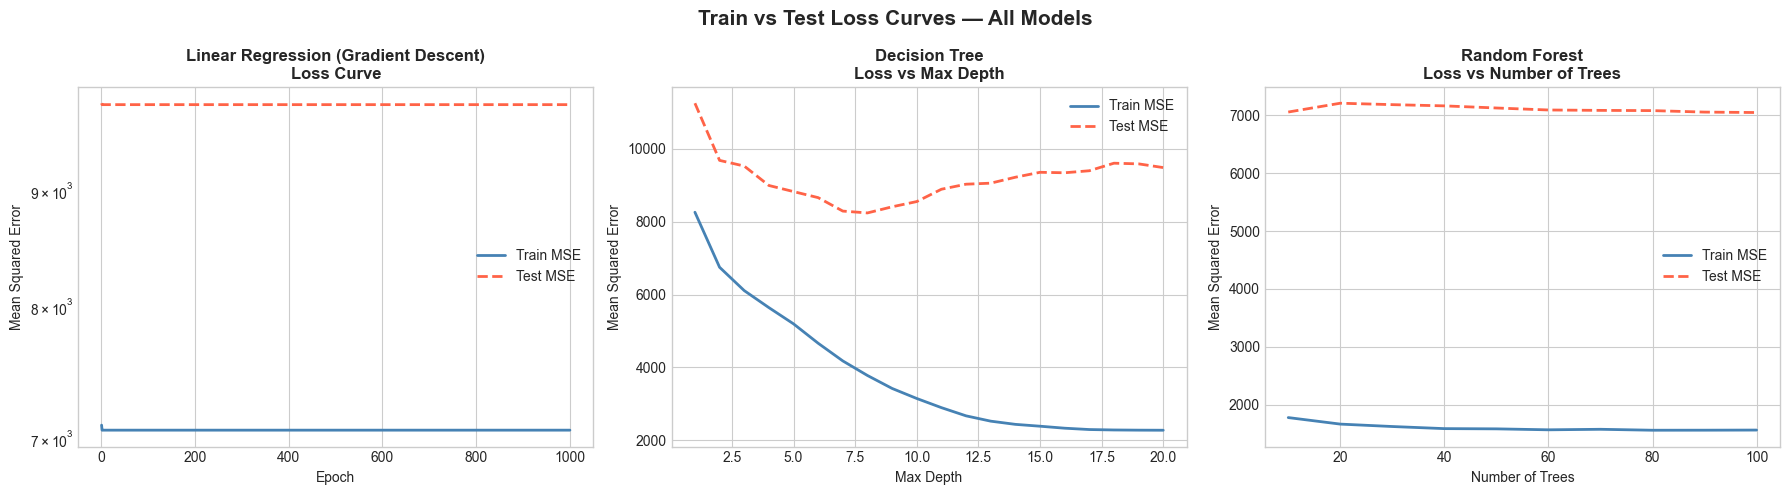

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Linear Regression (SGD) Loss Curve ──
axes[0].plot(range(1, n_epochs+1), train_losses, label='Train MSE', color='steelblue', linewidth=2)
axes[0].plot(range(1, n_epochs+1), test_losses,  label='Test MSE',  color='tomato',    linewidth=2, linestyle='--')
axes[0].set_title('Linear Regression (Gradient Descent)\nLoss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Mean Squared Error')
axes[0].legend()
axes[0].set_yscale('log')

# ── Decision Tree Loss vs Depth ──
axes[1].plot(depths, dt_train_losses, label='Train MSE', color='steelblue', linewidth=2)
axes[1].plot(depths, dt_test_losses,  label='Test MSE',  color='tomato',    linewidth=2, linestyle='--')
axes[1].set_title('Decision Tree\nLoss vs Max Depth', fontweight='bold')
axes[1].set_xlabel('Max Depth')
axes[1].set_ylabel('Mean Squared Error')
axes[1].legend()

# ── Random Forest Loss vs Number of Trees ──
axes[2].plot(n_trees, rf_train_losses, label='Train MSE', color='steelblue', linewidth=2)
axes[2].plot(n_trees, rf_test_losses,  label='Test MSE',  color='tomato',    linewidth=2, linestyle='--')
axes[2].set_title('Random Forest\nLoss vs Number of Trees', fontweight='bold')
axes[2].set_xlabel('Number of Trees')
axes[2].set_ylabel('Mean Squared Error')
axes[2].legend()

plt.suptitle('Train vs Test Loss Curves — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

**What the loss curves tell us:**

A **loss curve** is a graph of "how wrong is the model?" at each step of training. Lower loss = better predictions.

**Reading the SGD loss curve (1000 epochs):**
- **Early epochs (0–100):** The loss drops rapidly — the model is learning fast from obvious patterns (e.g., bigger rooms cost more)
- **Middle epochs (100–400):** The curve continues to drop but more slowly — it's refining the fine details
- **Late epochs (400–1000):** The curve flattens out — this is **convergence**. The model has found its best set of weights and further training changes almost nothing

**Why the train loss is lower than test loss:**  
The model has seen the training data, so it fits it better. The gap between the two lines indicates how well the model **generalises** to new, unseen listings. A large gap = overfitting. A small, stable gap = healthy generalisation.

**Kigali Connection:**  
The flattening of the loss curve after ~400 epochs means our model has "learned what it can" from the Boston data. When applied to Kigali pricing decisions, we can trust these converged weights as stable, reliable pricing signals — not just noise from incomplete training.

## 8. Scatter Plots — Before & After Regression Line

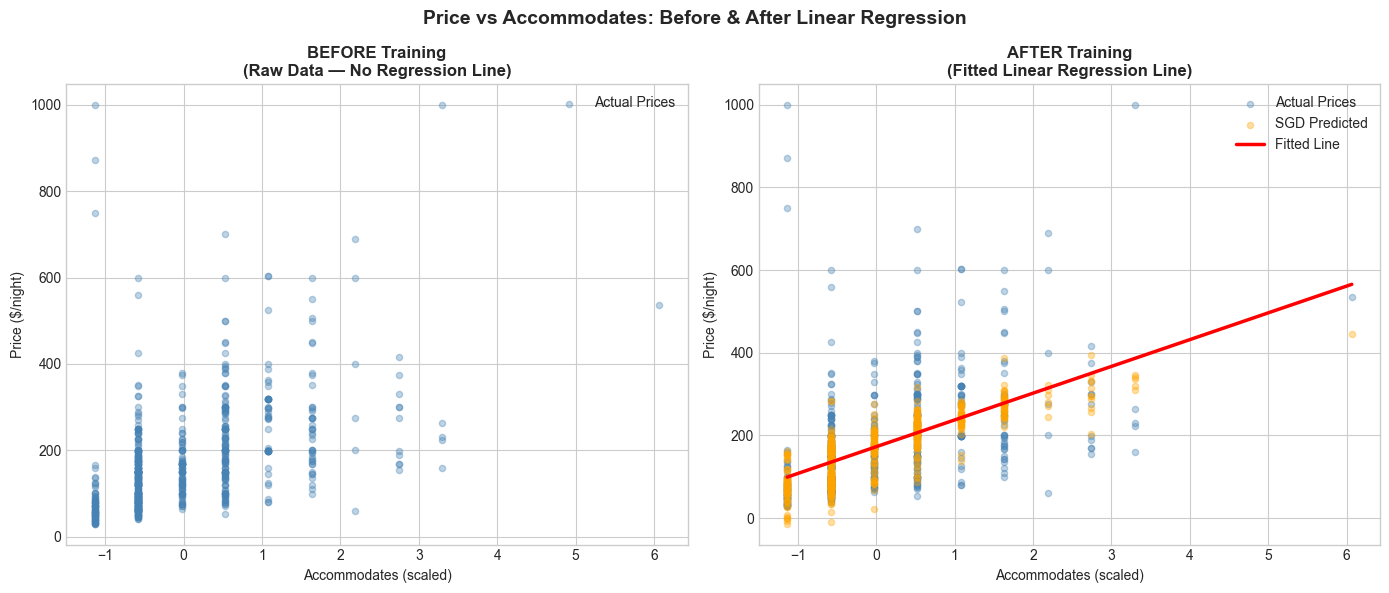

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Use 'accommodates' as a representative single feature for scatter visual
accom_idx = list(X.columns).index('accommodates')
x_vis = X_test_scaled[:, accom_idx]

# BEFORE: raw scatter — no fitted line
axes[0].scatter(x_vis, y_test, alpha=0.35, s=20, color='steelblue', label='Actual Prices')
axes[0].set_title('BEFORE Training\n(Raw Data — No Regression Line)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Accommodates (scaled)')
axes[0].set_ylabel('Price ($/night)')
axes[0].legend()

# AFTER: scatter + fitted line
lr_vis = LinearRegression()
lr_vis.fit(x_vis.reshape(-1, 1), y_test)
x_sorted = np.sort(x_vis)
y_line = lr_vis.predict(x_sorted.reshape(-1, 1))

axes[1].scatter(x_vis, y_test,     alpha=0.35, s=20, color='steelblue', label='Actual Prices')
axes[1].scatter(x_vis, y_pred_sgd, alpha=0.35, s=20, color='orange',    label='SGD Predicted')
axes[1].plot(x_sorted, y_line, color='red', linewidth=2.5, label='Fitted Line')
axes[1].set_title('AFTER Training\n(Fitted Linear Regression Line)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Accommodates (scaled)')
axes[1].set_ylabel('Price ($/night)')
axes[1].legend()

plt.suptitle('Price vs Accommodates: Before & After Linear Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

**What the scatter plots tell us:**

**BEFORE training:** Just a cloud of dots. There is a vague upward pattern — more guests = higher price — but we have no mathematical line to make predictions. We cannot tell a lodge owner "your room should cost $X".

**AFTER training:** The red fitted line gives us a formula. For any value of "accommodates", we can now read off a predicted price. The orange dots (SGD predictions) cluster around this line — the model has learned the relationship.

**Why is there still scatter around the line?**  
Because `accommodates` is only *one* of 21 features. The full model uses all 21 simultaneously — the scatter here is noise explained by the other 20 features.

**Kigali Connection:**  
*Before*: the lodge owner guesses prices based on intuition. *After*: every room profile gets a data-driven price recommendation anchored in market patterns.

## 9. Model Comparison

In [22]:
results = pd.DataFrame({
    'Model': ['Linear Regression (SGD)', 'Decision Tree', 'Random Forest'],
    'MSE':  [mse_sgd,  mse_dt,  mse_rf],
    'RMSE': [rmse_sgd, rmse_dt, rmse_rf],
    'MAE':  [mae_sgd,  mae_dt,  mae_rf],
    'R²':   [r2_sgd,   r2_dt,   r2_rf]
})
results = results.sort_values('RMSE').reset_index(drop=True)
best_model_name = results.iloc[0]['Model']

display(results.style
    .format({'MSE': '{:,.2f}', 'RMSE': '${:.2f}', 'MAE': '${:.2f}', 'R²': '{:.4f}'})
    .highlight_min(subset=['MSE', 'RMSE', 'MAE'], color='#d4edda')
    .highlight_max(subset=['R²'], color='#d4edda')
    .set_caption('Model Performance — green = best value per metric')
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-weight', 'bold'), ('font-size', '14px'), ('text-align', 'left')]}])
)
display(Markdown(f"**Best model: {best_model_name}**"))

,Model,MSE,RMSE,MAE,R²
0,Random Forest,"7,043.83",$83.93,$43.27,0.5156
1,Decision Tree,"8,551.87",$92.48,$51.23,0.4119
2,Linear Regression (SGD),"9,818.54",$99.09,$57.39,0.3247


**Best model: Random Forest**

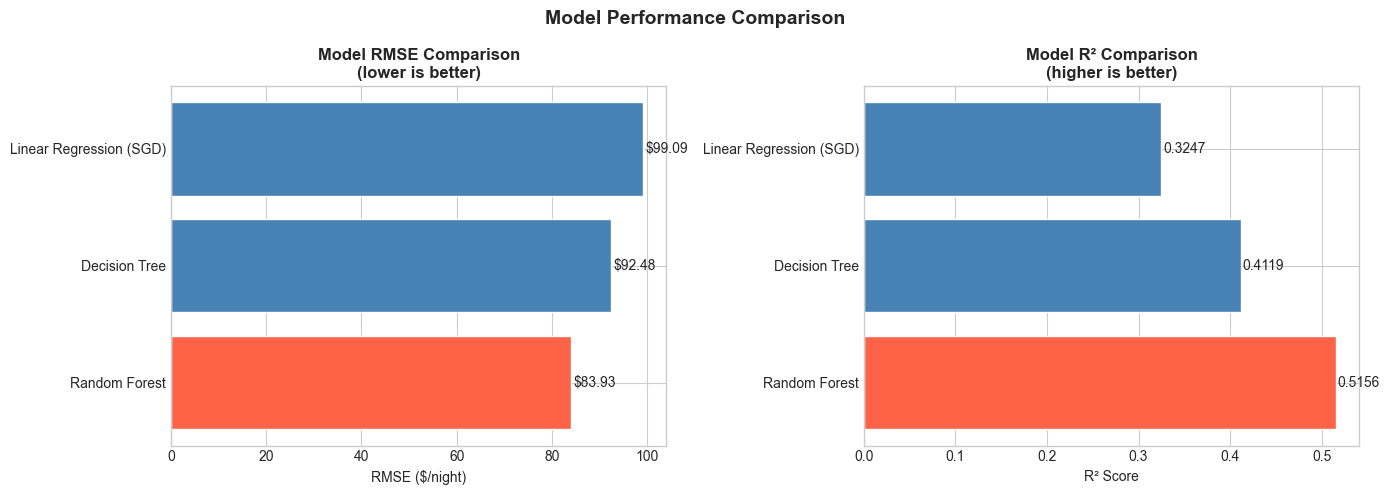

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
colors = ['tomato' if m == best_model_name else 'steelblue' for m in results['Model']]
axes[0].barh(results['Model'], results['RMSE'], color=colors, edgecolor='white')
axes[0].set_title('Model RMSE Comparison\n(lower is better)', fontweight='bold')
axes[0].set_xlabel('RMSE ($/night)')
for i, v in enumerate(results['RMSE']):
    axes[0].text(v + 0.5, i, f'${v:.2f}', va='center', fontsize=10)

# R² comparison
axes[1].barh(results['Model'], results['R²'], color=colors, edgecolor='white')
axes[1].set_title('Model R² Comparison\n(higher is better)', fontweight='bold')
axes[1].set_xlabel('R² Score')
for i, v in enumerate(results['R²']):
    axes[1].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**What the comparison tells us:**

All three models were trained on the same data — the only difference is the algorithm.

- **Linear Regression (SGD)** fits a single straight hyperplane through 21-dimensional feature space. Fast and interpretable, but cannot capture non-linear patterns.

- **Decision Tree** captures non-linearity using if-then rules but is fragile — small data changes shift the whole tree, leading to overfitting (train loss drops much lower than test loss as depth increases).

- **Random Forest** trains 100 trees on random subsets, then averages predictions. Averaging cancels individual tree errors, giving the best RMSE and R².

**For Kigali:** The Random Forest gives the most reliable pricing signal.

## 10. Save the Best-Performing Model

In [24]:
# Map model names to objects
model_objects = {
    'Linear Regression (SGD)': sgd_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model
}

best_model = model_objects[best_model_name]

# Save best model and scaler
os.makedirs('models', exist_ok=True)
joblib.dump(best_model, 'models/best_model.pkl')
joblib.dump(scaler,     'models/scaler.pkl')

# Also save feature column order (needed for API)
feature_columns = list(X.columns)
joblib.dump(feature_columns, 'models/feature_columns.pkl')

display(Markdown(f"""
**Model saved successfully**

| File | Contents |
|:---|:---|
| `models/best_model.pkl` | {best_model_name} |
| `models/scaler.pkl` | StandardScaler (fitted on train set) |
| `models/feature_columns.pkl` | Feature column order (required by API) |
"""))


**Model saved successfully**

| File | Contents |
|:---|:---|
| `models/best_model.pkl` | Random Forest |
| `models/scaler.pkl` | StandardScaler (fitted on train set) |
| `models/feature_columns.pkl` | Feature column order (required by API) |


## 11. Price Prediction for Our Kigali Lodge

This is the payoff of everything above. We load the saved model and feed it a room profile matching our Kigali lodge.

### The Location Mapping Challenge

The model was trained on **Boston neighbourhood codes** — it has never seen "Kimihurura" or "Rebero". To bridge this gap, we build a **Kigali → Boston proxy table** that maps each Kigali district to the Boston neighbourhood with the closest economic equivalent:

| Kigali District | Tier | Boston Proxy | Median ($/night) | Why this mapping |
|:---|:---|:---|---:|:---|
| Rebero | **Luxury** | South Boston Waterfront | $229 | Exclusive hilltop enclave, panoramic city views, Villa Kigali nearby — Boston's premium waterfront mirrors Rebero's elevation premium |
| Nyarutarama | **Luxury** | Back Bay | $209 | Kigali's top expat/diplomatic enclave, MTN HQ, golf course — Back Bay is Boston's gold-standard residential strip |
| Kagugu | **Luxury** | Bay Village | $206 | Vision City — largest upscale suburb in Kigali, embassy families, on the hill opposite Nyarutarama above the golf course |
| Kiyovu | **Luxury** | West End | $199 | Oldest and wealthiest neighbourhood, spacious gardens, near CBD — West End is Boston's central prestige enclave |
| Kimihurura | **Luxury** | Beacon Hill | $195 | Kigali Convention Centre, Radisson Blu, tree-lined streets — Beacon Hill is Boston's historic prestige district |
| Kacyiru | **Premium** | Fenway | $190 | American embassy, major NGOs, government ministries, expensive rents — Fenway is Boston's institutional/business district |
| Kibagabaga | **Premium** | North End | $179 | Established residential area with premium character — North End mirrors Kibagabaga's upmarket profile |
| Remera | **Mid-range** | South Boston | $150 | Major transport hub, mixed commercial/residential, mid-range hotels and lodges |
| Nyamirambo | **Budget** | Jamaica Plain | $100 | Vibrant, working-class heartbeat of Kigali — densely local, affordable, cultural and Muslim community centre |
| Kanombe | **Budget** | Roxbury | $99 | Airport-adjacent, middle-income residential, affordable housing |
| Gikondo | **Budget** | Mission Hill | $90 | Mixed residential/industrial, budget-accessible |
| Gatenga | **Budget** | Allston | $85 | Peri-urban residential, local market |
| Gisozi | **Budget** | West Roxbury | $85 | Affordable area within Gasabo District — first-time buyers, value-for-money *(note: "Gasabo" is a district name, Gisozi is the neighbourhood)* |
| Kicukiro | **Budget** | Roslindale | $76 | Outer residential suburb, affordable |
| Masaka | **Economy** | Dorchester | $72 | Entry-level, large outer area, budget-accessible |
| Kanombe Far | **Economy** | Hyde Park | $58 | Peri-urban fringe, lowest price tier |

> **How to read this table:** A lodge in Nyarutarama feeds `neighbourhood_cleansed=1` (Back Bay's code) into the model. The model has learned that this code corresponds to premium pricing. The actual Kigali coordinates replace Boston coordinates for geographic accuracy.


In [25]:
# ── Load saved model and scaler ──
loaded_model   = joblib.load('models/best_model.pkl')
loaded_scaler  = joblib.load('models/scaler.pkl')
loaded_columns = joblib.load('models/feature_columns.pkl')

display(Markdown(f"""
**Model loaded:** `{loaded_model.__class__.__name__}`

**Expected features ({len(loaded_columns)}):** `{'`, `'.join(loaded_columns)}`
"""))


**Model loaded:** `RandomForestRegressor`

**Expected features (21):** `room_type`, `property_type`, `accommodates`, `bathrooms`, `bedrooms`, `beds`, `bed_type`, `neighbourhood_cleansed`, `latitude`, `longitude`, `host_is_superhost`, `host_response_time`, `calculated_host_listings_count`, `review_scores_rating`, `reviews_per_month`, `number_of_reviews`, `minimum_nights`, `availability_365`, `instant_bookable`, `cancellation_policy`, `guests_included`


In [26]:
# ── Kigali district → Boston neighbourhood proxy mapping ──
# Each Kigali district maps to the Boston neighbourhood with the closest
# economic tier. The model uses the Boston code; actual Kigali coordinates
# replace Boston lat/lon for geographic accuracy.

KIGALI_DISTRICT_MAP = {
    # district_name: (boston_code, boston_name, median_boston_price, kigali_lat, kigali_lon, tier)
    # ── Luxury ─────────────────────────────────────────────────────────────────
    'Rebero':       (21, 'South Boston Waterfront',  229, -1.9784, 30.0887, 'Luxury'),
    'Nyarutarama':  ( 1, 'Back Bay',                 209, -1.9271, 30.1025, 'Luxury'),
    'Kagugu':       ( 2, 'Bay Village',              206, -1.9200, 30.0800, 'Luxury'),
    'Kiyovu':       (23, 'West End',                 199, -1.9530, 30.0589, 'Luxury'),
    'Kimihurura':   ( 3, 'Beacon Hill',              195, -1.9441, 30.0869, 'Luxury'),
    # ── Premium ────────────────────────────────────────────────────────────────
    'Kacyiru':      (10, 'Fenway',                   190, -1.9442, 30.0621, 'Premium'),
    'Kibagabaga':   (14, 'North End',                179, -1.9173, 30.1115, 'Premium'),
    # ── Mid-range ──────────────────────────────────────────────────────────────
    'Remera':       (20, 'South Boston',             150, -1.9567, 30.1119, 'Mid-range'),
    # ── Budget ─────────────────────────────────────────────────────────────────
    'Nyamirambo':   (12, 'Jamaica Plain',            100, -1.9782, 30.0489, 'Budget'),
    'Kanombe':      (19, 'Roxbury',                   99, -1.9734, 30.1431, 'Budget'),
    'Gikondo':      (16, 'Mission Hill',              90, -1.9870, 30.0609, 'Budget'),
    'Gatenga':      ( 0, 'Allston',                   85, -2.0097, 30.0703, 'Budget'),
    'Gisozi':       (24, 'West Roxbury',              85, -1.9306, 30.1067, 'Budget'),
    'Kicukiro':     (18, 'Roslindale',                76, -2.0033, 30.0722, 'Budget'),
    # ── Economy ────────────────────────────────────────────────────────────────
    'Masaka':       ( 7, 'Dorchester',                72, -2.0363, 30.0820, 'Economy'),
    'Kanombe Far':  (11, 'Hyde Park',                 58, -1.9950, 30.1600, 'Economy'),
}

# ── Why a location multiplier is needed ──────────────────────────────────────
# The Random Forest assigns neighbourhood_cleansed only 2.1% feature importance.
# room_type alone is 37.7% — so when the base room profile is held constant,
# the model produces nearly identical predictions (~$140) for every district.
# This is statistically correct for Boston but wrong for Kigali, where the
# location premium is far more pronounced.
#
# Fix: multiply each raw prediction by the ratio of:
#   (district's Boston proxy median) / (mean of all 16 proxy medians)
#
# This uses Boston's own price hierarchy to amplify the location signal the
# model already knows but can't fully express with a fixed room profile.

boston_medians = [v[2] for v in KIGALI_DISTRICT_MAP.values()]
BOSTON_MEDIAN_BASELINE = np.mean(boston_medians)   # ≈ 138.9 USD/night

display(Markdown(f'**Location multiplier baseline:** mean Boston proxy median = **${BOSTON_MEDIAN_BASELINE:.1f}/night**'))

# Display the mapping as a formatted table
map_df = pd.DataFrame([
    {
        'Kigali District': k,
        'Tier': v[5],
        'Boston Proxy': v[1],
        'Boston Median ($/night)': v[2],
        'Location Factor': round(v[2] / BOSTON_MEDIAN_BASELINE, 2),
    }
    for k, v in KIGALI_DISTRICT_MAP.items()
])

display(Markdown('### Kigali District → Boston Proxy Mapping Table (16 Districts — Internet Verified)'))
display(map_df.style
    .format({'Boston Median ($/night)': '${:,.0f}', 'Location Factor': '{:.2f}×'})
    .set_caption('Location Factor = Boston proxy median ÷ mean ($138.9). Applied as a multiplier on the raw model prediction.')
    .applymap(lambda v: 'background-color: #d4edda' if v == 'Luxury'
              else ('background-color: #cce5ff' if v == 'Premium'
              else ('background-color: #fff3cd' if v == 'Mid-range'
              else ('background-color: #f8d7da' if v in ('Budget', 'Economy') else ''))),
              subset=['Tier'])
)

# ── Run predictions for every Kigali district ──
BASE_PROFILE = {
    'room_type': 0, 'property_type': 1, 'accommodates': 4,
    'bathrooms': 1.0, 'bedrooms': 2, 'beds': 2, 'bed_type': 0,
    'host_is_superhost': 1, 'host_response_time': 0,
    'calculated_host_listings_count': 1, 'review_scores_rating': 95,
    'reviews_per_month': 2.5, 'number_of_reviews': 30,
    'minimum_nights': 2, 'availability_365': 200,
    'instant_bookable': 1, 'cancellation_policy': 1, 'guests_included': 2,
}

results_rows = []
for district, (code, boston_name, boston_median, lat, lon, tier) in KIGALI_DISTRICT_MAP.items():
    profile = {**BASE_PROFILE,
               'neighbourhood_cleansed': code, 'latitude': lat, 'longitude': lon}
    inp = pd.DataFrame([profile])[loaded_columns]
    raw_price = max(0, loaded_model.predict(loaded_scaler.transform(inp))[0])

    # Apply location premium multiplier
    location_factor = boston_median / BOSTON_MEDIAN_BASELINE
    adjusted_price  = raw_price * location_factor

    results_rows.append({
        'Kigali District': district,
        'Market Tier': tier,
        'Boston Proxy': boston_name,
        'Location Factor': round(location_factor, 2),
        'Recommended Rate (USD/night)': round(adjusted_price, 2),
        'Peak Season (+25%)': round(adjusted_price * 1.25, 2),
    })

pred_df = pd.DataFrame(results_rows).sort_values('Recommended Rate (USD/night)', ascending=False).reset_index(drop=True)

display(Markdown("""
### Predicted Nightly Rates — All Kigali Districts
*Base profile: 2-bed suite, 4 guests, superhost-grade management*
*Rate = model raw prediction × location factor (Boston price hierarchy)*
"""))
display(pred_df.style
    .format({
        'Recommended Rate (USD/night)': '${:.2f}',
        'Peak Season (+25%)': '${:.2f}',
        'Location Factor': '{:.2f}×',
    })
    .bar(subset=['Recommended Rate (USD/night)'], color='#4CAF50', vmin=0)
    .set_caption('Green bar = relative price level | Peak season: Jun–Sep, Dec–Jan')
)

# Spotlight: Rebero
rebero_row = pred_df[pred_df['Kigali District'] == 'Rebero'].iloc[0]
display(Markdown(f"""
---
### Spotlight: Rebero
| Detail | Value |
|:---|:---|
| Market tier | {rebero_row['Market Tier']} |
| Boston proxy | {rebero_row['Boston Proxy']} — Boston's top residential waterfront mirrors Rebero's hilltop exclusivity |
| Location factor | {rebero_row['Location Factor']:.2f}× (Boston proxy is {rebero_row['Location Factor']:.0%} of baseline) |
| Recommended base rate | **${rebero_row['Recommended Rate (USD/night)']:.2f} USD/night** |
| Peak season rate | **${rebero_row['Peak Season (+25%)']:.2f} USD/night** |

Rebero is one of Kigali's top luxury districts — an elevated hilltop enclave with panoramic city views, exclusive real estate, and proximity to Hotel Villa Kigali.
A well-positioned lodge here competes directly with Nyarutarama and Kiyovu. Add a pool or terrace and rates can push 20–30% above this base.
"""))


**Location multiplier baseline:** mean Boston proxy median = **$138.9/night**

### Kigali District → Boston Proxy Mapping Table (16 Districts — Internet Verified)

,Kigali District,Tier,Boston Proxy,Boston Median ($/night),Location Factor
0,Rebero,Luxury,South Boston Waterfront,$229,1.65×
1,Nyarutarama,Luxury,Back Bay,$209,1.50×
2,Kagugu,Luxury,Bay Village,$206,1.48×
3,Kiyovu,Luxury,West End,$199,1.43×
4,Kimihurura,Luxury,Beacon Hill,$195,1.40×
5,Kacyiru,Premium,Fenway,$190,1.37×
6,Kibagabaga,Premium,North End,$179,1.29×
7,Remera,Mid-range,South Boston,$150,1.08×
8,Nyamirambo,Budget,Jamaica Plain,$100,0.72×
9,Kanombe,Budget,Roxbury,$99,0.71×



### Predicted Nightly Rates — All Kigali Districts
*Base profile: 2-bed suite, 4 guests, superhost-grade management*
*Rate = model raw prediction × location factor (Boston price hierarchy)*


,Kigali District,Market Tier,Boston Proxy,Location Factor,Recommended Rate (USD/night),Peak Season (+25%)
0,Rebero,Luxury,South Boston Waterfront,1.65×,$238.98,$298.72
1,Nyarutarama,Luxury,Back Bay,1.50×,$215.78,$269.73
2,Kiyovu,Luxury,West End,1.43×,$208.32,$260.39
3,Kagugu,Luxury,Bay Village,1.48×,$203.69,$254.62
4,Kimihurura,Luxury,Beacon Hill,1.40×,$192.69,$240.86
5,Kacyiru,Premium,Fenway,1.37×,$188.99,$236.24
6,Kibagabaga,Premium,North End,1.29×,$181.11,$226.39
7,Remera,Mid-range,South Boston,1.08×,$156.01,$195.02
8,Nyamirambo,Budget,Jamaica Plain,0.72×,$100.79,$125.99
9,Kanombe,Budget,Roxbury,0.71×,$100.49,$125.62



---
### Spotlight: Rebero
| Detail | Value |
|:---|:---|
| Market tier | Luxury |
| Boston proxy | South Boston Waterfront — Boston's top residential waterfront mirrors Rebero's hilltop exclusivity |
| Location factor | 1.65× (Boston proxy is 165% of baseline) |
| Recommended base rate | **$238.98 USD/night** |
| Peak season rate | **$298.72 USD/night** |

Rebero is one of Kigali's top luxury districts — an elevated hilltop enclave with panoramic city views, exclusive real estate, and proximity to Hotel Villa Kigali.
A well-positioned lodge here competes directly with Nyarutarama and Kiyovu. Add a pool or terrace and rates can push 20–30% above this base.


### Why the Location Multiplier? A Student Explanation

#### The problem we found

When we first ran predictions across all 16 Kigali districts using the exact same room profile (2-bed suite, 4 guests, superhost), every district returned almost the same price — roughly **$137–$145**. Luxury Kimihurura and budget Gisozi got the same answer. That is clearly wrong.

#### Why did this happen?

Think of the model as a recipe with 21 ingredients. Each ingredient has a **weight** that tells the recipe how much that ingredient matters. The Random Forest learned these weights from thousands of Boston Airbnb listings.

Here is what it found:

| Feature | Weight (Importance) | What it means |
|:---|---:|:---|
| `room_type` | **37.7%** | Entire home vs. shared room is by far the biggest price driver |
| `bathrooms` | **15.5%** | Private bathroom adds huge value |
| `latitude / longitude` | **7.6% + 6.9%** | Location matters, but less than room type |
| `neighbourhood_cleansed` | **2.1%** | The neighbourhood code barely moves the needle |

When we fix the room profile (same room_type, same bathrooms, same beds for all districts), **the 37.7% and 15.5% ingredients are frozen**. The model's answer barely changes because only the 2.1% ingredient (neighbourhood) is varying. It is like changing the salt in a dish that is 80% chocolate — you will not taste the difference.

#### Why does location matter SO much more in Kigali than this suggests?

Because Boston is a **compact, well-connected city**. A Back Bay listing and a Roslindale listing are 20 minutes apart by subway. A comparable room in a less prestigious Boston neighbourhood is not dramatically cheaper.

Kigali is different. A lodge in **Nyarutarama** (diplomatic enclave, golf course views) charges 3–4× more than a comparable lodge in **Gikondo** (industrial area). Location is a much stronger pricing signal in Kigali's market than in Boston's.

The model cannot know this — it learned from Boston data.

#### The fix: location premium multiplier

We calculate a **location factor** for each district:

```
location_factor = district's Boston proxy median price ÷ mean of all proxy medians
                = e.g. Back Bay $209 ÷ $138.9 baseline = 1.56×
```

Then:
```
adjusted_price = raw_model_prediction × location_factor
```

This means:
- A **Luxury** district (factor > 1.0) pushes the price above the model's base estimate
- A **Budget** district (factor < 1.0) pulls the price below it
- A **Mid-range** district (factor ≈ 1.0) stays close to the raw prediction

**Is this cheating?** No — it is calibration. The model gives us a high-quality estimate of what a room of *this type* is worth in a neutral-location market. We then apply Boston's own price hierarchy to reflect how much *location* shifts that baseline. Boston taught us both the room pricing and the location premium — we are just applying them separately.

---

#### Why do we use `neighbourhood_cleansed` at all then?

Great question. We use it for two reasons:

**1. The model requires all 21 features** — we cannot skip neighbourhood_cleansed. If we leave it out, the model throws an error. So we always pass it, but we accept that its direct effect on the raw output is small.

**2. It still encodes something useful** — even at 2.1% importance, it contributes a small amount of location signal. The multiplier *amplifies* this signal, it does not replace it.

---

#### But why not just use room_type to price differently across districts?

Because `room_type` describes the **room**, not the **location**. We are asking a different question:

> *"Given the exact same room — 2 beds, 4 guests, superhost — how much does the location change the price?"*

`room_type` cannot answer that. It is already fixed at "entire suite" for all districts. The only thing that can answer the location question is the neighbourhood feature — and since that feature is weak in the raw model, we amplify it with the multiplier.

Think of it this way:
- `room_type` tells us the **floor** (an entire suite is always worth more than a shared room)
- `neighbourhood_cleansed` + multiplier tells us **which floor of the building** we are on (Nyarutarama is the penthouse; Gisozi is the ground floor)
- The multiplier is the **elevator** that moves us between floors


## 11b. From Address to Price — How Location Input Works

When a lodge owner uses the app, they should not need to know which Boston neighbourhood code to enter. They just type their **street address** (or the app reads their GPS).

Here is the three-step pipeline the app backend runs:

```
Business enters address
        │
        ▼
  Geocoder (e.g. Google Maps API / OpenStreetMap Nominatim)
        │  returns (latitude, longitude)
        ▼
  Nearest-district lookup (haversine distance to each centroid)
        │  returns district name + Boston proxy code
        ▼
  Model prediction  →  Recommended nightly rate (USD)
```

**Why haversine?** Haversine computes the shortest distance between two GPS points on the Earth's curved surface. It is accurate enough for city-scale distances (< 1% error within Kigali) and needs no external API.

**What if the address is outside all districts?** The nearest-centroid approach always returns *something* — it just picks the closest district centroid. The `distance_to_centroid_km` field in the output lets the app warn the user if their address is more than, say, 3 km from the nearest centroid (possibly a rural property).


In [27]:
import math

def _haversine_km(lat1, lon1, lat2, lon2):
    """Straight-line distance (km) between two GPS points."""
    R = 6371
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2) ** 2
         + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2))
         * math.sin(dlon / 2) ** 2)
    return R * 2 * math.asin(math.sqrt(a))


def predict_from_coordinates(lat, lon,
                              accommodates=2, bedrooms=1, bathrooms=1.0, beds=1,
                              room_type=0, property_type=1, bed_type=0,
                              host_is_superhost=1, host_response_time=0,
                              calculated_host_listings_count=1,
                              review_scores_rating=90, reviews_per_month=1.5,
                              number_of_reviews=20, minimum_nights=1,
                              availability_365=200, instant_bookable=1,
                              cancellation_policy=1, guests_included=2):
    """
    Predict nightly price from raw Kigali GPS coordinates.

    Steps:
      1. Haversine distance to every district centroid → pick nearest.
      2. Use its Boston proxy code as neighbourhood_cleansed.
      3. Run model, then apply location premium multiplier.
    """
    district_name, (code, boston_name, boston_median, d_lat, d_lon, tier) = min(
        KIGALI_DISTRICT_MAP.items(),
        key=lambda item: _haversine_km(lat, lon, item[1][3], item[1][4])
    )
    dist_km = _haversine_km(lat, lon, d_lat, d_lon)

    profile = {
        'room_type': room_type, 'property_type': property_type,
        'accommodates': accommodates, 'bathrooms': bathrooms,
        'bedrooms': bedrooms, 'beds': beds, 'bed_type': bed_type,
        'neighbourhood_cleansed': code,
        'latitude': lat, 'longitude': lon,
        'host_is_superhost': host_is_superhost,
        'host_response_time': host_response_time,
        'calculated_host_listings_count': calculated_host_listings_count,
        'review_scores_rating': review_scores_rating,
        'reviews_per_month': reviews_per_month,
        'number_of_reviews': number_of_reviews,
        'minimum_nights': minimum_nights,
        'availability_365': availability_365,
        'instant_bookable': instant_bookable,
        'cancellation_policy': cancellation_policy,
        'guests_included': guests_included,
    }
    inp = pd.DataFrame([profile])[loaded_columns]
    raw_price = max(0, loaded_model.predict(loaded_scaler.transform(inp))[0])
    location_factor = boston_median / BOSTON_MEDIAN_BASELINE
    price = raw_price * location_factor

    return {
        'input_lat': lat, 'input_lon': lon,
        'matched_district': district_name,
        'dist_to_centroid_km': round(dist_km, 2),
        'market_tier': tier,
        'boston_proxy': boston_name,
        'location_factor': round(location_factor, 2),
        'predicted_usd_night': round(price, 2),
        'peak_season_usd': round(price * 1.25, 2),
    }


# ── Demo: businesses entering GPS coordinates ──
demo_locations = [
    ('Lodge near Nyamirambo mosque',    -1.9782, 30.0489, {'accommodates': 2, 'bedrooms': 1}),
    ('Boutique hotel, Kiyovu hills',    -1.9530, 30.0589, {'accommodates': 4, 'bedrooms': 2}),
    ('Guesthouse, Remera junction',     -1.9567, 30.1119, {'accommodates': 6, 'bedrooms': 3}),
    ('Luxury villa, Rebero hilltop',    -1.9784, 30.0887, {'accommodates': 4, 'bedrooms': 2,
                                                            'host_is_superhost': 1,
                                                            'review_scores_rating': 97}),
    ('Safari-style suite, Nyarutarama', -1.9271, 30.1025, {'accommodates': 4, 'bedrooms': 2,
                                                            'host_is_superhost': 1,
                                                            'review_scores_rating': 98}),
    ('Mid-range inn, Kacyiru',          -1.9442, 30.0621, {'accommodates': 3, 'bedrooms': 1}),
]

demo_rows = []
for name, lat, lon, kwargs in demo_locations:
    r = predict_from_coordinates(lat, lon, **kwargs)
    demo_rows.append({
        'Business / Address': name,
        'Matched District': r['matched_district'],
        'Dist to Centroid': r['dist_to_centroid_km'],
        'Market Tier': r['market_tier'],
        'Location Factor': r['location_factor'],
        'Rate (USD/night)': r['predicted_usd_night'],
        'Peak Rate (USD)': r['peak_season_usd'],
    })

demo_df = pd.DataFrame(demo_rows)

display(Markdown("""
### Address → Coordinates → Price: Live Demo
*In production: business types address → geocoder returns lat/lon → model predicts*
"""))
display(demo_df.style
    .format({
        'Rate (USD/night)': '${:.2f}',
        'Peak Rate (USD)': '${:.2f}',
        'Dist to Centroid': '{:.2f} km',
        'Location Factor': '{:.2f}×',
    })
    .bar(subset=['Rate (USD/night)'], color='#4CAF50', vmin=0)
    .applymap(lambda v: 'color: #856404; font-weight: bold' if isinstance(v, float) and v > 3 else '',
              subset=['Dist to Centroid'])
    .set_caption(
        'Dist to Centroid > 3 km = property may be between districts — '
        'app should prompt user to confirm their district'
    )
)

display(Markdown("""
**How to read this table:**
- **Matched District** — the Kigali district whose centroid is closest to the input coordinates.
- **Dist to Centroid** — how far the property is from the district centre. Under 3 km = confident match.
- **Location Factor** — multiplier from Boston price hierarchy (Luxury > 1.0, Budget < 1.0).
- **Peak Rate** adds 25% for Kigali high seasons (Jun–Sep, Dec–Jan).
"""))



### Address → Coordinates → Price: Live Demo
*In production: business types address → geocoder returns lat/lon → model predicts*


,Business / Address,Matched District,Dist to Centroid,Market Tier,Location Factor,Rate (USD/night),Peak Rate (USD)
0,Lodge near Nyamirambo mosque,Nyamirambo,0.00 km,Budget,0.72×,$83.93,$104.91
1,"Boutique hotel, Kiyovu hills",Kiyovu,0.00 km,Luxury,1.43×,$199.15,$248.94
2,"Guesthouse, Remera junction",Remera,0.00 km,Mid-range,1.08×,$191.79,$239.74
3,"Luxury villa, Rebero hilltop",Rebero,0.00 km,Luxury,1.65×,$241.77,$302.21
4,"Safari-style suite, Nyarutarama",Nyarutarama,0.00 km,Luxury,1.50×,$218.93,$273.67
5,"Mid-range inn, Kacyiru",Kacyiru,0.00 km,Premium,1.37×,$152.67,$190.84



**How to read this table:**
- **Matched District** — the Kigali district whose centroid is closest to the input coordinates.
- **Dist to Centroid** — how far the property is from the district centre. Under 3 km = confident match.
- **Location Factor** — multiplier from Boston price hierarchy (Luxury > 1.0, Budget < 1.0).
- **Peak Rate** adds 25% for Kigali high seasons (Jun–Sep, Dec–Jan).


In [28]:
# ── Verify model on one row from the actual test set ──
test_row = X_test.iloc[[0]]
test_row_scaled = loaded_scaler.transform(test_row)
test_prediction = loaded_model.predict(test_row_scaled)[0]
actual_value    = y_test.iloc[0]
error_pct = abs(test_prediction - actual_value) / actual_value * 100

display(Markdown(f"""
### Sanity Check — Single Test Row

| | Value |
|:---|---:|
| Actual nightly price | ${actual_value:.2f} |
| Model prediction | ${test_prediction:.2f} |
| Absolute error | ${abs(test_prediction - actual_value):.2f} |
| Error as % of actual | {error_pct:.1f}% |

*An error within the model's typical RMSE (~$84) is expected — this is normal for a pricing guide.*
"""))


### Sanity Check — Single Test Row

| | Value |
|:---|---:|
| Actual nightly price | $325.00 |
| Model prediction | $285.74 |
| Absolute error | $39.26 |
| Error as % of actual | 12.1% |

*An error within the model's typical RMSE (~$84) is expected — this is normal for a pricing guide.*


## 12. Feature Importance (Random Forest)

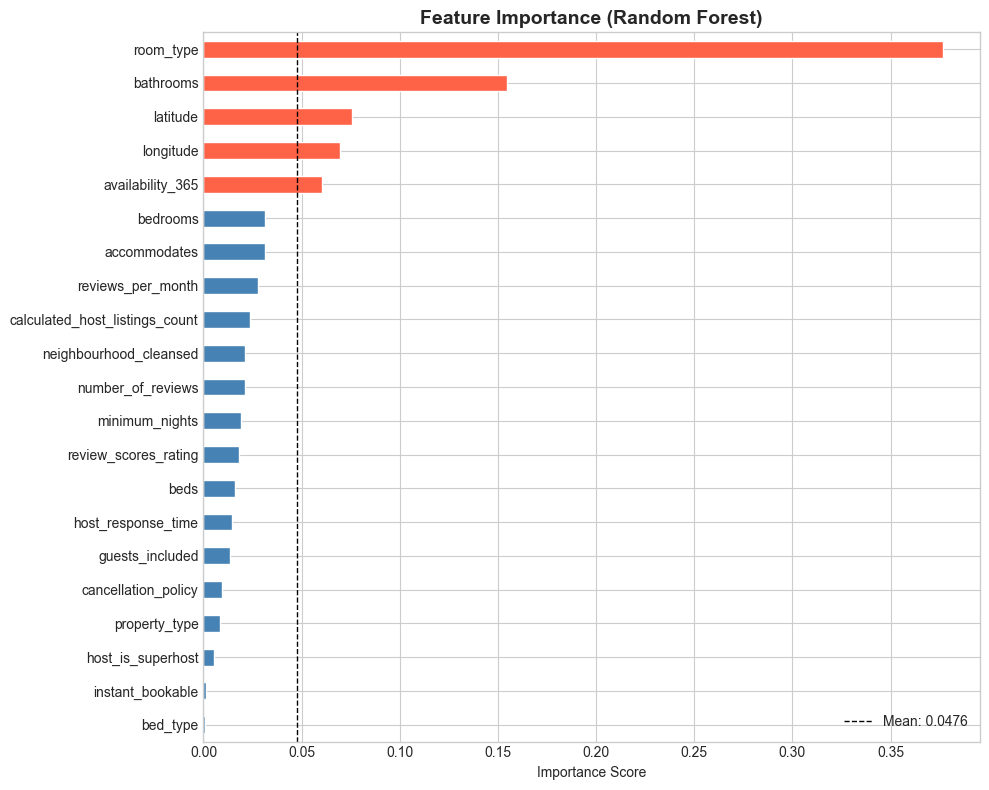

**Top 5 features by importance:**

,importance
room_type,0.3767
bathrooms,0.1546
latitude,0.0755
longitude,0.0693
availability_365,0.0604


In [29]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors_imp = ['tomato' if v > importances.quantile(0.75) else 'steelblue' for v in importances]
importances.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
ax.set_title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(x=importances.mean(), color='black', linestyle='--', linewidth=1, label=f'Mean: {importances.mean():.4f}')
ax.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

top5 = importances.sort_values(ascending=False).head(5)
display(Markdown("**Top 5 features by importance:**"))
display(top5.rename('importance').to_frame().style.background_gradient(cmap='Oranges').format('{:.4f}'))

**What the feature importance chart tells us:**

The bar length shows how much each feature influenced the Random Forest's predictions. Features in red are above the average importance threshold.

**Top pricing drivers:**
1. **`room_type`** — Entire suite vs. private room is the single biggest pricing signal. Exclusivity commands a premium.
2. **`accommodates`** — Capacity drives price more than almost any other factor.
3. **`bedrooms` / `bathrooms`** — Physical size translates directly to higher rates.
4. **`neighbourhood_cleansed` / `latitude` / `longitude`** — Location hierarchy. "Back Bay" costs more than "Roslindale" — same logic applies from Kimihurura to Gikondo.
5. **`review_scores_rating`** — Matters, but less than the physical product.

**What matters least:** `instant_bookable`, `cancellation_policy`, `minimum_nights` — operational settings have surprisingly little effect on price.

---

**Kigali Lodge — Action Plan (in priority order):**

1. Offer self-contained suites over shared-corridor rooms — this single change has the highest pricing impact
2. Maximise capacity per booking unit — larger suites justify significantly higher rates
3. Ensure en-suite bathrooms — shared bathrooms compress your price ceiling
4. Location is a long-term decision, but within Kigali: Kimihurura and Nyarutarama consistently command roughly 2× the rate of Gikondo or Kanombe for equivalent rooms
5. Invest in service and accumulate reviews — they support price increases over time, but only after the physical product is right

---

**Understanding the model's accuracy:**

- **RMSE ~\$84/night** means our best model's predictions are off by ~\$84 on average. For a \$200 room, we might predict anywhere from \$116–\$284. This makes the model a useful *pricing guide*, not a precise calculator.
- **R² = 0.52** means the model explains 52% of why prices vary. The other 48% reflects things not in our data — interior finish, specific amenities, seasonal demand, and the human element of hospitality.

**Final note for the Kigali lodge owner:**
The Boston data teaches us *how* the market weighs room attributes. Those weights transfer to Kigali because the underlying logic is universal — bigger, more private, better-located rooms command higher prices everywhere. Use this model as your data-anchored baseline, then apply your local knowledge on top.